## Movie Recommendation System with Collaborative Filtering

### Data Import and Cleaning

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df_meta = pd.read_json('data/raw/metadata_updated.json', lines=True)
df_meta.head()

,title,directedBy,starring,avgRating,imdbId,item_id
0,Toy Story (1995),John Lasseter,"Tim Allen, Tom Hanks, Don Rickles, Jim Varney,...",3.89146,114709,1
1,Jumanji (1995),Joe Johnston,"Jonathan Hyde, Bradley Pierce, Robin Williams,...",3.26605,113497,2
2,Grumpier Old Men (1995),Howard Deutch,"Jack Lemmon, Walter Matthau, Ann-Margret , Sop...",3.17146,113228,3
3,Waiting to Exhale (1995),Forest Whitaker,"Angela Bassett, Loretta Devine, Whitney Housto...",2.86824,114885,4
4,Father of the Bride Part II (1995),Charles Shyer,"Steve Martin, Martin Short, Diane Keaton, Kimb...",3.07620,113041,5


In [3]:
df_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84661 entries, 0 to 84660
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       84661 non-null  object 
 1   directedBy  84661 non-null  object 
 2   starring    84661 non-null  object 
 3   avgRating   84661 non-null  float64
 4   imdbId      84661 non-null  int64  
 5   item_id     84661 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 3.9+ MB


In [4]:
df_ratings = pd.read_json('data/raw/ratings.json', lines=True)
df_ratings.head()

,item_id,user_id,rating
0,5,997206,3.0
1,10,997206,4.0
2,13,997206,4.0
3,17,997206,5.0
4,21,997206,4.0


In [5]:
df_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28490116 entries, 0 to 28490115
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   item_id  int64  
 1   user_id  int64  
 2   rating   float64
dtypes: float64(1), int64(2)
memory usage: 652.1 MB


In [6]:
df_ratings.isnull().sum()

item_id    0
user_id    0
rating     0
dtype: int64

In [7]:
# Aggregate to remove duplicate ratings
df_ratings = df_ratings.groupby(['user_id', 'item_id'], as_index=False).agg({'rating': 'mean'})

In [8]:
df_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28249191 entries, 0 to 28249190
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   user_id  int64  
 1   item_id  int64  
 2   rating   float64
dtypes: float64(1), int64(2)
memory usage: 646.6 MB


In [9]:
df_ratings['rating'].describe()

count    2.824919e+07
mean     3.527041e+00
std      1.063333e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

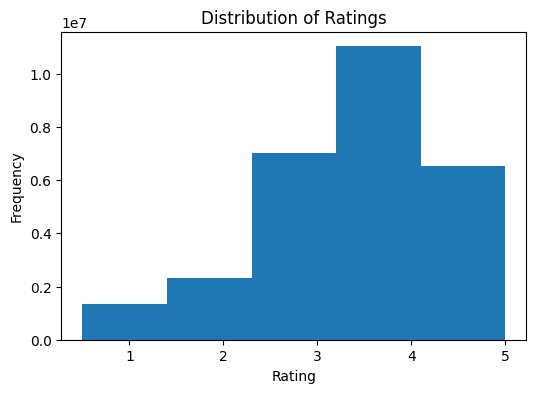

In [10]:
plt.figure(figsize=(6, 4))
plt.hist(df_ratings['rating'], bins=5)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [11]:
df_ratings.head()

,user_id,item_id,rating
0,0,1,3.5
1,0,110,5.0
2,0,144,2.0
3,0,260,5.0
4,0,318,4.0


### Collaborative Filtering with NCF Model

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode user_id and item_id to numerical values
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df_ratings['user_idx'] = user_encoder.fit_transform(df_ratings['user_id'])
df_ratings['item_idx'] = item_encoder.fit_transform(df_ratings['item_id'])

# Split into training and test sets
train_data, test_data = train_test_split(df_ratings, test_size=0.2, random_state=42)

# Get the number of unique users and items
num_users = df_ratings['user_idx'].nunique()
num_items = df_ratings['item_idx'].nunique()

print(f"Number of users: {num_users}, Number of items: {num_items}")

Number of users: 247383, Number of items: 67873


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout

def create_ncf_model(num_users, num_items, embedding_dim=20):
    # Input layers
    user_input = Input(shape=(1,), name="user_input")
    item_input = Input(shape=(1,), name="item_input")
    
    # Embedding layers (reduced dimensions)
    user_embedding = Embedding(input_dim=num_users, output_dim=embedding_dim, name="user_embedding")(user_input)
    item_embedding = Embedding(input_dim=num_items, output_dim=embedding_dim, name="item_embedding")(item_input)
    
    # Flatten embeddings
    user_vec = Flatten(name="user_flatten")(user_embedding)
    item_vec = Flatten(name="item_flatten")(item_embedding)
    
    # Concatenate user and item embeddings
    interaction = Concatenate(name="interaction")([user_vec, item_vec])
    
    # Fully connected layers (reduced sizes)
    dense = Dense(64, activation="relu", name="dense_1")(interaction)
    dense = Dropout(0.2, name="dropout_1")(dense)
    dense = Dense(32, activation="relu", name="dense_2")(dense)
    dense = Dropout(0.2, name="dropout_2")(dense)
    output = Dense(1, activation="linear", name="output")(dense)  # Predict rating
    
    # Build and compile model
    model = Model(inputs=[user_input, item_input], outputs=output)
    model.compile(optimizer="adam", loss="mse", metrics=["mse"])
    return model

# Create the model
ncf_model = create_ncf_model(num_users, num_items)
ncf_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 20)     │  4,947,660 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 20)     │  1,357,460 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_flatten        │ (None, 20)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_flatten        │ (None, 20)        │          0 │ item_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interaction         │ (None, 40)        │          0 │ user_flatten[0][… │
│ (Concatenate)       │                   │            │ item_flatten[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      2,624 │ interaction[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,309,857 (24.07 MB)

 Trainable params: 6,309,857 (24.07 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Prepare training data
x_train = [train_data['user_idx'].values, train_data['item_idx'].values]
y_train = train_data['rating'].values

# Train the model
ncf_model.fit(
    x=x_train,
    y=y_train,
    batch_size=1024,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
19863/19863 ━━━━━━━━━━━━━━━━━━━━ 203s 10ms/step - loss: 1.1231 - mse: 1.1231 - val_loss: 0.7252 - val_mse: 0.7252
Epoch 2/15
19863/19863 ━━━━━━━━━━━━━━━━━━━━ 210s 11ms/step - loss: 0.7112 - mse: 0.7112 - val_loss: 0.7080 - val_mse: 0.7080
Epoch 3/15
19863/19863 ━━━━━━━━━━━━━━━━━━━━ 211s 11ms/step - loss: 0.6814 - mse: 0.6814 - val_loss: 0.6945 - val_mse: 0.6945
Epoch 4/15
19863/19863 ━━━━━━━━━━━━━━━━━━━━ 211s 11ms/step - loss: 0.6581 - mse: 0.6581 - val_loss: 0.6845 - val_mse: 0.6845
Epoch 5/15
19863/19863 ━━━━━━━━━━━━━━━━━━━━ 213s 11ms/step - loss: 0.6387 - mse: 0.6387 - val_loss: 0.6788 - val_mse: 0.6788
Epoch 6/15
19863/19863 ━━━━━━━━━━━━━━━━━━━━ 1187s 60ms/step - loss: 0.6246 - mse: 0.6246 - val_loss: 0.6715 - val_mse: 0.6715
Epoch 7/15
19863/19863 ━━━━━━━━━━━━━━━━━━━━ 1256s 63ms/step - loss: 0.6129 - mse: 0.6129 - val_loss: 0.6688 - val_mse: 0.6688
Epoch 8/15
19863/19863 ━━━━━━━━━━━━━━━━━━━━ 606s 30ms/step - loss: 0.6039 - mse: 0.6039 - val_loss: 0.6690 - val_mse: 0.669

### Evaluate Model Accuracy (RMSE)

In [15]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Prepare test data
x_test = [test_data['user_idx'].values, test_data['item_idx'].values]
y_test = test_data['rating'].values

# Predict ratings for test data
y_pred = ncf_model.predict(x_test)

# Calculate RMSE
rmse = sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {rmse:.4f}")

176558/176558 ━━━━━━━━━━━━━━━━━━━━ 38s 212us/step
Test RMSE: 0.8180


### Model Recommendations

In [25]:
def recommend_top_movies(user_id, df_meta, n=5):
    
    if user_id not in user_encoder.classes_:
        return "User not found."

    # Encode user_id
    user_idx = user_encoder.transform([user_id])[0]

    # Get all items the user hasn't rated
    rated_items = train_data[train_data['user_idx'] == user_idx]['item_idx'].unique()
    unrated_items = np.setdiff1d(df_ratings['item_idx'].unique(), rated_items)

    # Prepare inputs for prediction
    user_array = np.full(len(unrated_items), user_idx)  # Same user for all unrated items
    item_array = unrated_items

    # Predict ratings for all unrated items
    predicted_ratings = ncf_model.predict([user_array, item_array], verbose=0)

    # Create a DataFrame of predictions
    df_predictions = pd.DataFrame({
        'item_idx': unrated_items,
        'predicted_rating': predicted_ratings.flatten()
    })

    # Get the top N recommendations
    df_top_pred = df_predictions.sort_values(by='predicted_rating', ascending=False).head(n*2)

    # Map item indices back to item IDs
    df_top_pred['item_id'] = item_encoder.inverse_transform(df_top_pred['item_idx'])
    
    # Merge with metadata
    df_top_pred = df_top_pred[['item_id', 'predicted_rating']].merge(
        df_meta[['item_id', 'title', 'avgRating']],
        on='item_id',
        how='inner'
    )

    return df_top_pred[:n]

In [26]:
# Example 1 (valid)
user_id = 10020
recommendations = recommend_top_movies(user_id, df_meta, n=5)
print(f"Top 5 recommendations for {user_id}: \n{recommendations}")

Top 5 recommendations for 10020: 
   item_id  predicted_rating                          title  avgRating
0   172719          5.024623     Notre Dame de Paris (1998)    4.17857
1     3226          4.810836  Hellhounds on My Trail (1999)    4.16667
2    90592          4.748853    How to Die in Oregon (2011)    4.10145
3    83560          4.733185                 Macario (1960)    3.95238
4    86237          4.725561             Connections (1978)    3.79091


In [27]:
# Example 2 (valid)
user_id = 997206
recommendations = recommend_top_movies(user_id, df_meta, n=5)
print(f"Top 5 recommendations for {user_id}: \n{recommendations}")

Top 5 recommendations for 997206: 
   item_id  predicted_rating                                title  avgRating
0   172719          4.958755           Notre Dame de Paris (1998)    4.17857
1   142871          4.908478          O Pátio das Cantigas (1942)    4.46296
2   184393          4.707923  The Criminal Excellency Fund (2018)    4.56250
3   189159          4.677622       Born in the USSR: 14 Up (1998)    4.12500
4     3226          4.665954        Hellhounds on My Trail (1999)    4.16667


In [28]:
# Example 3 (new or invalid user)
user_id = 10000
recommendations = recommend_top_movies(user_id, df_meta, n=5)
print(f"Top 5 recommendations for {user_id}: \n{recommendations}")

Top 5 recommendations for 10000: 
User not found.
